In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from aaa_tps.systems.two_dimensional_double_wells import BistableDoubleWell

In [3]:
bsdw = BistableDoubleWell(A=15, B=0.25)

bsdw_E = bsdw.energy_function
bsdw_F = bsdw.force_function

In [4]:
from aaa_tps.states.states import circular_state

bsdw_state_A = circular_state(center=(-2.,0), axes=(1,1), angle=0, radius=0.15) 
bsdw_state_B = circular_state(center=(2.,0), axes=(1,1), angle=0, radius=0.15) 

In [5]:
x_values = np.linspace(-3.3, 3.3, 100)
y_values = np.linspace(-3.3, 3.3, 100)

x_grid, y_grid = np.meshgrid(x_values, y_values)

U = np.zeros((len(x_values), len(y_values)))
Fx = np.zeros((len(x_values), len(y_values)))
Fy = np.zeros((len(x_values), len(y_values)))

in_state_A = np.zeros((len(x_values), len(y_values)))
in_state_B = np.zeros((len(x_values), len(y_values)))

for i in range(len(x_values)):
    for j in range(len(y_values)):

        U[i,j] = bsdw_E(np.array([x_grid[i, j], y_grid[i, j]]))
        
        f = bsdw_F(np.array([x_grid[i, j], y_grid[i, j]]))
        Fx[i,j] = f[0]
        Fy[i,j] = f[1]

        in_state_A[i,j] = bsdw_state_A.is_in_state(np.array([x_grid[i, j], y_grid[i, j]]))
        in_state_B[i,j] = bsdw_state_B.is_in_state(np.array([x_grid[i, j], y_grid[i, j]]))

nsample = 1
x_grid_sub = x_grid[::nsample, ::nsample]
y_grid_sub = y_grid[::nsample, ::nsample]
Fx_sub = Fx[::nsample, ::nsample]
Fy_sub = Fy[::nsample, ::nsample]

Fnorm = np.sqrt(Fx_sub**2 + Fy_sub**2)
fx = Fx_sub / (Fnorm + 1e-12)
fy = Fy_sub / (Fnorm + 1e-12)

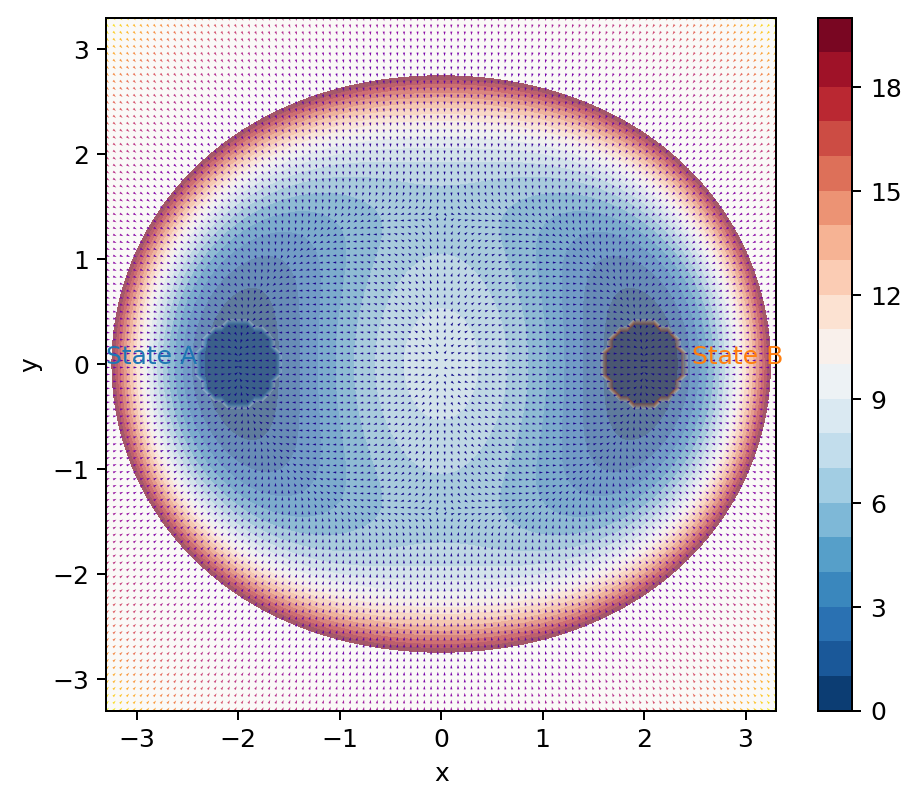

In [6]:
fig, ax = plt.subplots(1, figsize=(6,5), dpi=180)

cont = ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.2)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.2)
quiv = ax.quiver(x_grid_sub, y_grid_sub, fx, fy, Fnorm, cmap='plasma')
ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.colorbar(cont, ax=ax)

plt.show()

In [7]:
n_replicas = 5 # Number of TPS replicas
total_trials = 12500 # Number of TPS trial steps
equilibration_trials = 2500 # Before saving trajectories, do these steps
path_output_frequency = 1 # Save a trajectoy ever path_output_frequency steps
path_length_output_frequency = 1 # Save a trajectoy ever path_output_frequency steps

max_path_length = 25000   # path length for fixed length TPS, maximum path length for flexible length TPS
configuration_output_frequency = 1 # How often configurations are saved on a path

# Numerical integrators parameters
beta = 1
timestep = 0.001
diffusion_coefficient = 1

In [8]:
from functools import partial
from aaa_tps.utils.flexible_length_tps import generate_path

generate_path = partial(generate_path, force_function = bsdw.force_function,
                                       beta=beta,
                                       timestep=timestep,
                                       diffusion_coefficient=diffusion_coefficient)

In [9]:
current_path = np.array([np.linspace(-2.000, 2.000, max_path_length-1),np.linspace(0., 0., max_path_length-1)]).T

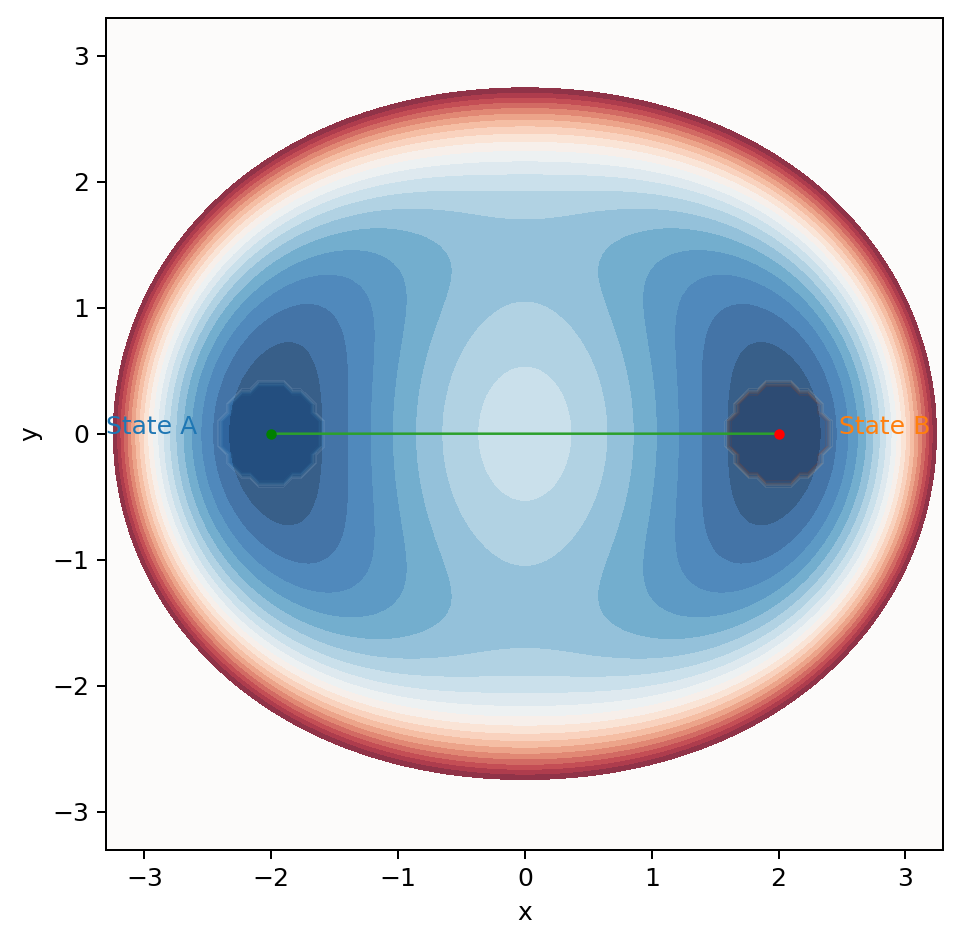

In [10]:
fig, ax = plt.subplots(1, figsize=(6,6), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [11]:
from aaa_tps.TPS_algorithms.twoway_shooting import TwoWayShootingTPS

from aaa_tps.utils.selection_probabilities import GaussianSelection
from aaa_tps.cvs.cvs import linear_cv

p_sel = GaussianSelection(cv=linear_cv(a=1, b=0), k=20.5, cv_ref=0)

tps_simulation_2w = TwoWayShootingTPS(max_path_length=max_path_length,
                                      state_A=bsdw_state_A,
                                      state_B=bsdw_state_B,
                                      generate_path=generate_path,
                                      p_sel=p_sel,
                                      init_path=current_path,
                                      output_dir="./output/twoway_shooting/bsdw/Gaussian",
                                      n_replicas=n_replicas)

In [12]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1
for replica in range(starting_replica, ending_replica, replica_stride):
    
    tps_simulation_2w.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [02:08<00:00, 96.97trials/s] 


In [13]:
init_path_fn = os.path.join(tps_simulation_2w.output_dir, "final_path_2w.txt")
current_path = np.loadtxt(init_path_fn)

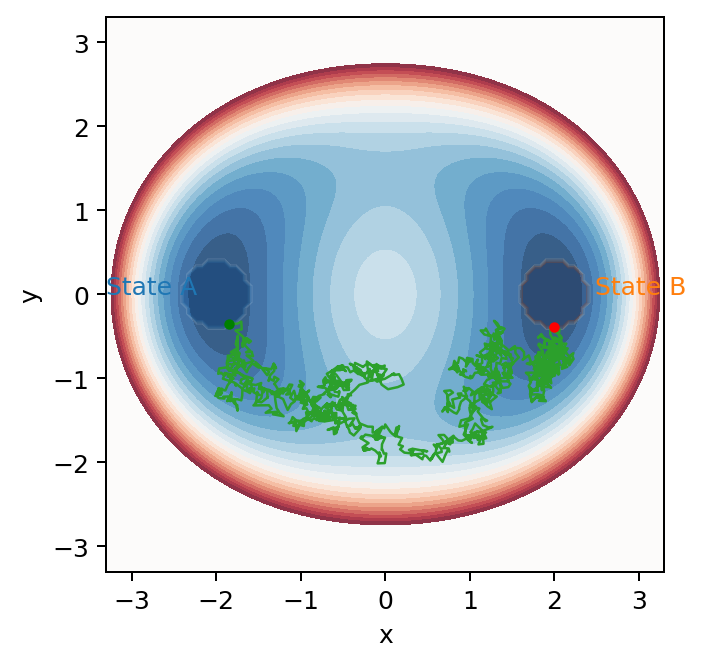

In [14]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [15]:
from aaa_tps.TPS_algorithms.oneway_shooting import OneWayShootingTPS

from aaa_tps.utils.selection_probabilities import GaussianSelection
from aaa_tps.cvs.cvs import linear_cv

p_sel = GaussianSelection(cv=linear_cv(a=1, b=0), k=12.5, cv_ref=0)

tps_simulation_1w = OneWayShootingTPS(max_path_length=max_path_length,
                                      state_A=bsdw_state_A,
                                      state_B=bsdw_state_B,
                                      generate_path=generate_path,
                                      p_sel=p_sel,
                                      init_path=current_path,
                                      output_dir="./output/oneway_shooting/bsdw/Gaussian",
                                      n_replicas=n_replicas)

In [16]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1
for replica in range(starting_replica, ending_replica, replica_stride):
    
    tps_simulation_1w.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [01:04<00:00, 194.85trials/s]


In [17]:
init_path_fn = os.path.join(tps_simulation_1w.output_dir, "final_path_1w.txt")
current_path = np.loadtxt(init_path_fn)

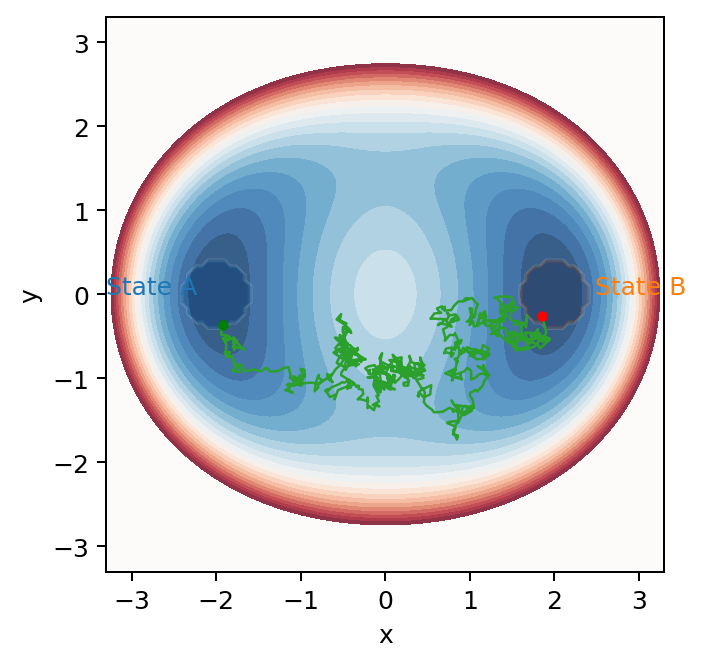

In [18]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [19]:
from aaa_tps.TPS_algorithms.ARA_TPS import ARA_TPS

from aaa_tps.utils.selection_probabilities import UniformSelection

p_sel = UniformSelection()

tps_simulation_ARA_TPS_Unif = ARA_TPS(max_path_length=max_path_length,
                                   state_A=bsdw_state_A,
                                   state_B=bsdw_state_B,
                                   generate_path=generate_path,
                                   p_sel=p_sel,
                                   init_path=current_path,
                                   output_dir="./output/ARA-TPS/bsdw/Uniform/",
                                   n_replicas=n_replicas)

In [20]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1

for replica in range(starting_replica, ending_replica, replica_stride):
    
    tps_simulation_ARA_TPS_Unif.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [00:39<00:00, 316.82trials/s]


In [21]:
init_path_fn = os.path.join(tps_simulation_ARA_TPS_Unif.output_dir, "final_path_ARA-TPS.txt")
current_path = np.loadtxt(init_path_fn)

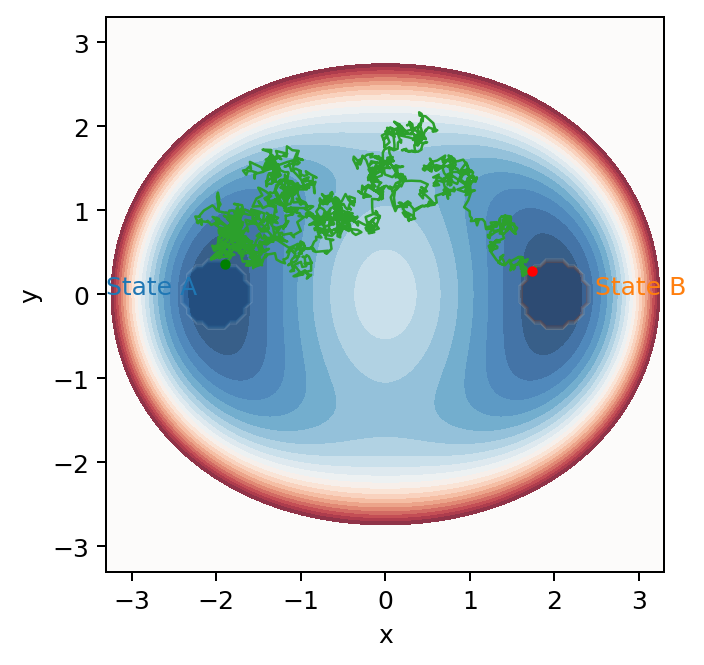

In [22]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [23]:
from aaa_tps.TPS_algorithms.ARA_TPS import ARA_TPS

from aaa_tps.utils.selection_probabilities import GaussianSelection
from aaa_tps.cvs.cvs import linear_cv

p_sel = GaussianSelection(cv=linear_cv(a=1, b=0), k=12.5, cv_ref=0)

tps_simulation_ARA_TPS_Gaus = ARA_TPS(max_path_length=max_path_length,
                                   state_A=bsdw_state_A,
                                   state_B=bsdw_state_B,
                                   generate_path=generate_path,
                                   p_sel=p_sel,
                                   init_path=current_path,
                                   output_dir="./output/ARA-TPS/bsdw/Gaussian/",
                                   n_replicas=n_replicas)

In [24]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1
for replica in range(starting_replica, ending_replica, replica_stride):
        
    tps_simulation_ARA_TPS_Gaus.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [01:03<00:00, 198.24trials/s]


In [25]:
init_path_fn = os.path.join(tps_simulation_ARA_TPS_Gaus.output_dir, "final_path_ARA-TPS.txt")
current_path = np.loadtxt(init_path_fn)

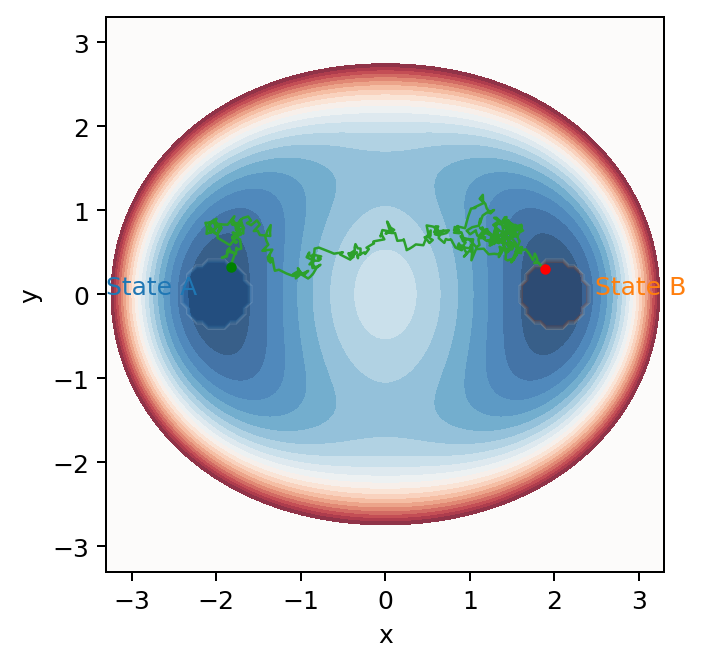

In [26]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [27]:
from aaa_tps.TPS_algorithms.AAA_TPS import AAA_TPS

from aaa_tps.utils.selection_probabilities import UniformSelection

p_sel = UniformSelection()

tps_simulation_AAA_TPS_Unif = AAA_TPS(max_path_length=max_path_length,
                                state_A=bsdw_state_A,
                                state_B=bsdw_state_B,
                                generate_path=generate_path,
                                p_sel=p_sel,
                                init_path=current_path,
                                output_dir="./output/AAA-TPS/bsdw/Uniform",
                                n_replicas=n_replicas)

In [31]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1
for replica in range(starting_replica, ending_replica, replica_stride):
    
    tps_simulation_AAA_TPS_Unif.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [00:40<00:00, 307.01trials/s]


In [32]:
init_path_fn = os.path.join(tps_simulation_AAA_TPS_Unif.output_dir, "final_path_AAA-TPS.txt")
current_path = np.loadtxt(init_path_fn)

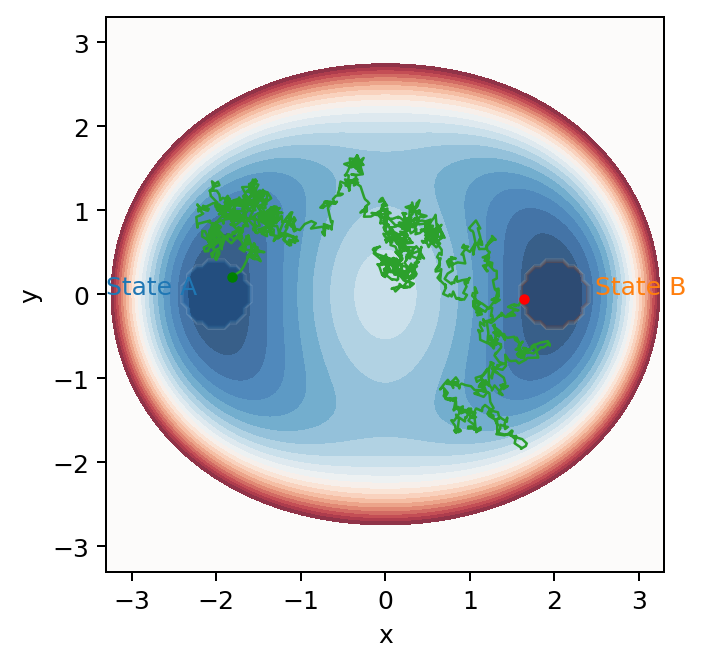

In [33]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [34]:
from aaa_tps.TPS_algorithms.AAA_TPS import AAA_TPS

from aaa_tps.utils.selection_probabilities import GaussianSelection
from aaa_tps.cvs.cvs import linear_cv

p_sel = GaussianSelection(cv=linear_cv(a=1, b=0), k=12.5, cv_ref=0)

tps_simulation_AAA_TPS_Gaus = AAA_TPS(max_path_length=max_path_length,
                                state_A=bsdw_state_A,
                                state_B=bsdw_state_B,
                                generate_path=generate_path,
                                p_sel=p_sel,
                                init_path=current_path,
                                output_dir="./output/AAA-TPS/bsdw/Gaussian",
                                n_replicas=n_replicas)

In [35]:
starting_replica = 0
ending_replica = n_replicas
replica_stride = 1
for replica in range(starting_replica, ending_replica, replica_stride):
    
    tps_simulation_AAA_TPS_Gaus.run_tps_simulation(total_trials,
                           configuration_output_frequency,
                           path_length_output_frequency,
                           path_output_frequency,
                           force_evaluation_output_frequency=path_length_output_frequency,
                           dump_output_frequency=0,
                           equilibration_trials=equilibration_trials,
                           replica=replica)

Replica 0005: 100%|██████████| 12500/12500 [01:06<00:00, 189.30trials/s]


In [36]:
init_path_fn = os.path.join(tps_simulation_AAA_TPS_Gaus.output_dir, "final_path_AAA-TPS.txt")
current_path = np.loadtxt(init_path_fn)

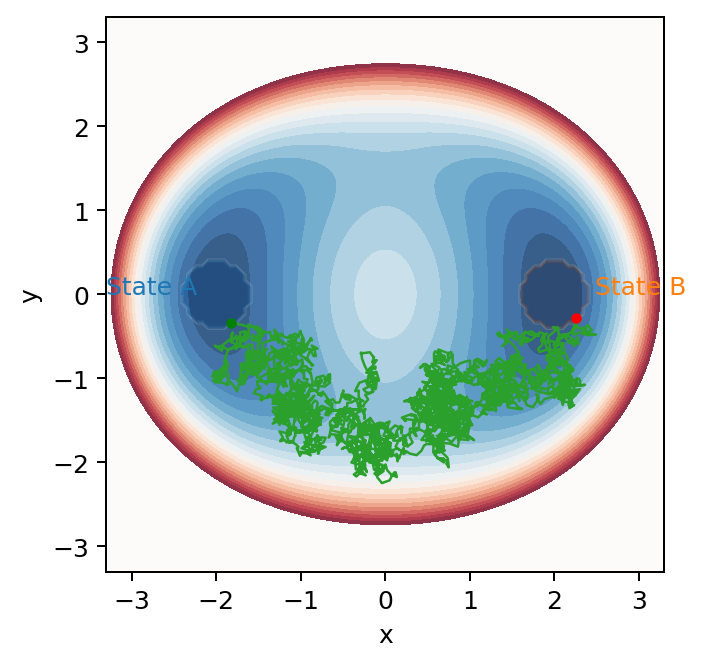

In [37]:
fig, ax = plt.subplots(1, figsize=(4,4), dpi=180)

ax.contourf(x_grid, y_grid, U-np.min(U), levels=np.linspace(0, 20, 21), cmap="RdBu_r")
ax.contourf(x_grid, y_grid, in_state_A, cmap="Blues", alpha=0.1)
ax.contourf(x_grid, y_grid, in_state_B, cmap="Oranges", alpha=0.1)

plt.plot(current_path[:,0], current_path[:,1], c="C2", lw=1)

plt.scatter(current_path[0,0], current_path[0,1], c="g", s=10, zorder=10)
plt.scatter(current_path[-1,0], current_path[-1,1], c="r", s=10, zorder=10)

ax.text(0.00, 0.5, "State A", transform=ax.transAxes, c="C0")
ax.text(0.875, 0.5, "State B", transform=ax.transAxes, c="C1")

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()